In [26]:
#Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [27]:
#Load Dataset
df = pd.read_csv("Iris.csv")

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (150, 6)
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [28]:
#Select 2 Classes
df = df[df["Species"].isin(["Iris-versicolor", "Iris-virginica"])]

In [29]:
#Select 2 Features
X = df[["PetalLengthCm", "PetalWidthCm"]]
y = df["Species"]

# Convert class names to 0 and 1
y = y.map({
    "Iris-versicolor": 0,
    "Iris-virginica": 1
})

In [30]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [31]:
#Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
#Linear SVM
linear_svm = SVC(
    kernel="linear",
    C=1
)

linear_svm.fit(X_train_scaled, y_train)

linear_pred = linear_svm.predict(X_test_scaled)

print("LINEAR SVM")
print("Accuracy:", accuracy_score(y_test, linear_pred))
print(classification_report(y_test, linear_pred))

LINEAR SVM
Accuracy: 0.8
              precision    recall  f1-score   support

           0       0.75      0.90      0.82        10
           1       0.88      0.70      0.78        10

    accuracy                           0.80        20
   macro avg       0.81      0.80      0.80        20
weighted avg       0.81      0.80      0.80        20



In [33]:
#Non-linear SVM using RBF kernel
rbf_svm = SVC(
    kernel="rbf",
    C=1,
    gamma="scale"
)

rbf_svm.fit(X_train_scaled, y_train)

rbf_pred = rbf_svm.predict(X_test_scaled)

print("RBF SVM")
print("Accuracy:", accuracy_score(y_test, rbf_pred))
print(classification_report(y_test, rbf_pred))

RBF SVM
Accuracy: 0.85
              precision    recall  f1-score   support

           0       0.82      0.90      0.86        10
           1       0.89      0.80      0.84        10

    accuracy                           0.85        20
   macro avg       0.85      0.85      0.85        20
weighted avg       0.85      0.85      0.85        20



In [34]:
#Function to plot decision boundary
def plot_decision_boundary(model, X, y, title):

    x_min = X[:, 0].min() - 1
    x_max = X[:, 0].max() + 1

    y_min = X[:, 1].min() - 1
    y_max = X[:, 1].max() + 1

    xx, yy = __import__("numpy").meshgrid(
        __import__("numpy").arange(x_min, x_max, 0.02),
        __import__("numpy").arange(y_min, y_max, 0.02)
    )

    Z = model.predict(
        __import__("numpy").c_[xx.ravel(), yy.ravel()]
    )

    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))

    plt.contourf(
        xx,
        yy,
        Z,
        alpha=0.25
    )

    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        edgecolors="k"
    )

    # Highlight support vectors
    plt.scatter(
        model.support_vectors_[:, 0],
        model.support_vectors_[:, 1],
        s=100,
        facecolors="none",
        edgecolors="black",
        linewidths=1.5,
        label="Support Vectors"
    )

    plt.xlabel("Petal Length")
    plt.ylabel("Petal Width")
    plt.title(title)
    plt.legend()
    plt.show()

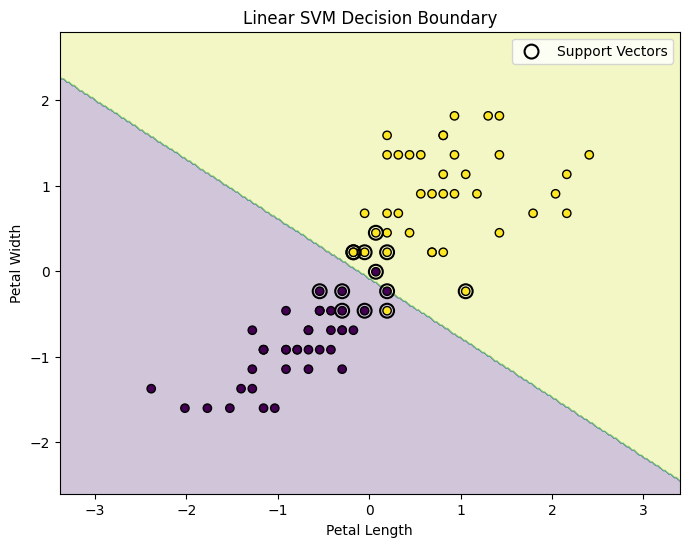

In [35]:
#Visualize Linear SVM
plot_decision_boundary(
    linear_svm,
    X_train_scaled,
    y_train,
    "Linear SVM Decision Boundary"
)

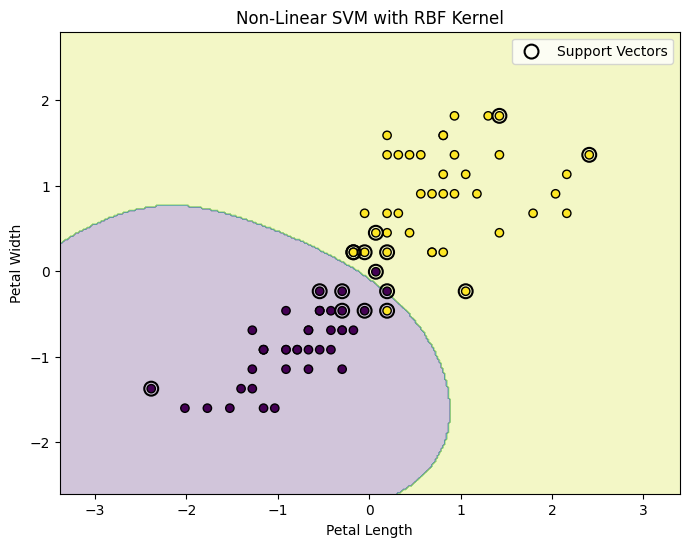

In [36]:
#Visualize RBF SVM
plot_decision_boundary(
    rbf_svm,
    X_train_scaled,
    y_train,
    "Non-Linear SVM with RBF Kernel"
)